# **Experiment 3 Features Engineering**

## Input

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt


from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression

In [2]:
cp = pd.read_csv("/content/CarPrice (1).csv") #load csv file

In [3]:
cp.head()

,car_ID,symboling,CarName,fueltype,aspiration,doornumber,carbody,drivewheel,enginelocation,wheelbase,...,enginesize,fuelsystem,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
0,1,3,alfa-romero giulia,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,13495.0
1,2,3,alfa-romero stelvio,gas,std,two,convertible,rwd,front,88.6,...,130,mpfi,3.47,2.68,9.0,111,5000,21,27,16500.0
2,3,1,alfa-romero Quadrifoglio,gas,std,two,hatchback,rwd,front,94.5,...,152,mpfi,2.68,3.47,9.0,154,5000,19,26,16500.0
3,4,2,audi 100 ls,gas,std,four,sedan,fwd,front,99.8,...,109,mpfi,3.19,3.40,10.0,102,5500,24,30,13950.0
4,5,2,audi 100ls,gas,std,four,sedan,4wd,front,99.4,...,136,mpfi,3.19,3.40,8.0,115,5500,18,22,17450.0


In [4]:
cp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 205 entries, 0 to 204
Data columns (total 26 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   car_ID            205 non-null    int64  
 1   symboling         205 non-null    int64  
 2   CarName           205 non-null    object 
 3   fueltype          205 non-null    object 
 4   aspiration        205 non-null    object 
 5   doornumber        205 non-null    object 
 6   carbody           205 non-null    object 
 7   drivewheel        205 non-null    object 
 8   enginelocation    205 non-null    object 
 9   wheelbase         205 non-null    float64
 10  carlength         205 non-null    float64
 11  carwidth          205 non-null    float64
 12  carheight         205 non-null    float64
 13  curbweight        205 non-null    int64  
 14  enginetype        205 non-null    object 
 15  cylindernumber    205 non-null    object 
 16  enginesize        205 non-null    int64  
 1

In [5]:
cp.describe()

,car_ID,symboling,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,peakrpm,citympg,highwaympg,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,103.000000,0.834146,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,5125.121951,25.219512,30.751220,13276.710571
std,59.322565,1.245307,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,476.985643,6.542142,6.886443,7988.852332
min,1.000000,-2.000000,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,4150.000000,13.000000,16.000000,5118.000000
25%,52.000000,0.000000,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,4800.000000,19.000000,25.000000,7788.000000
50%,103.000000,1.000000,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,5200.000000,24.000000,30.000000,10295.000000
75%,154.000000,2.000000,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,5500.000000,30.000000,34.000000,16503.000000
max,205.000000,3.000000,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,6600.000000,49.000000,54.000000,45400.000000


## CO Relation Graph

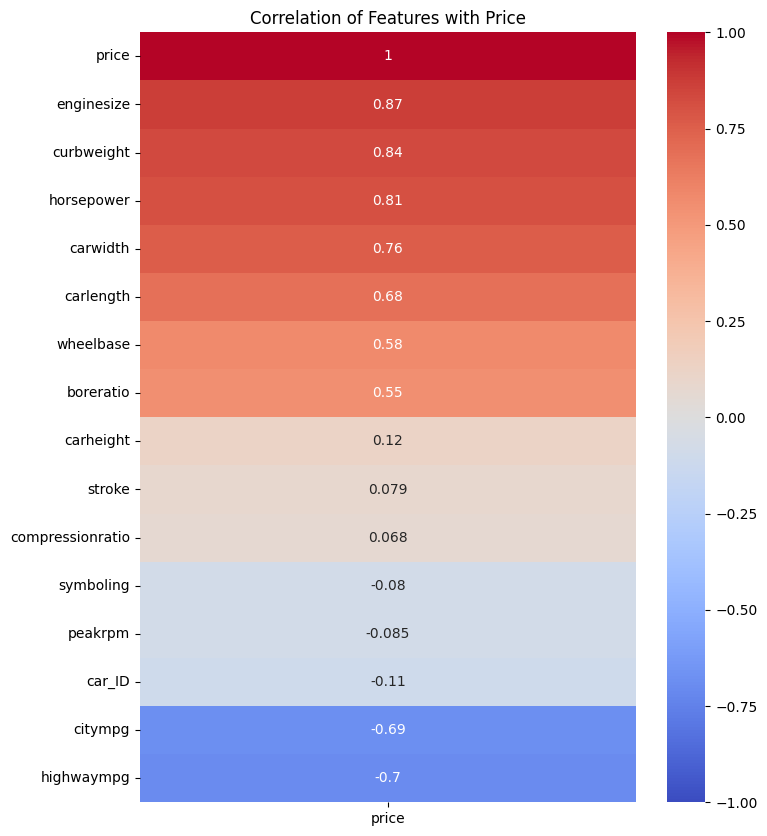

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = cp.corr(numeric_only=True)

# Correlation of all features with price
plt.figure(figsize=(8,10))
sns.heatmap(corr_matrix[['price']].sort_values(by='price', ascending=False),
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            vmax=1)

plt.title("Correlation of Features with Price")
plt.show()

## Data Cleaning

In [7]:
# Drop selected features
cp = cp.drop(columns=[
    'peakrpm',
    'car_ID',
    'symboling',
    'citympg',
    'highwaympg'
])

# Check the remaining columns
print(cp.columns)

Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'wheelbase', 'carlength', 'carwidth',
       'carheight', 'curbweight', 'enginetype', 'cylindernumber', 'enginesize',
       'fuelsystem', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
       'price'],
      dtype='object')


In [8]:
cp.describe()

,wheelbase,carlength,carwidth,carheight,curbweight,enginesize,boreratio,stroke,compressionratio,horsepower,price
count,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000,205.000000
mean,98.756585,174.049268,65.907805,53.724878,2555.565854,126.907317,3.329756,3.255415,10.142537,104.117073,13276.710571
std,6.021776,12.337289,2.145204,2.443522,520.680204,41.642693,0.270844,0.313597,3.972040,39.544167,7988.852332
min,86.600000,141.100000,60.300000,47.800000,1488.000000,61.000000,2.540000,2.070000,7.000000,48.000000,5118.000000
25%,94.500000,166.300000,64.100000,52.000000,2145.000000,97.000000,3.150000,3.110000,8.600000,70.000000,7788.000000
50%,97.000000,173.200000,65.500000,54.100000,2414.000000,120.000000,3.310000,3.290000,9.000000,95.000000,10295.000000
75%,102.400000,183.100000,66.900000,55.500000,2935.000000,141.000000,3.580000,3.410000,9.400000,116.000000,16503.000000
max,120.900000,208.100000,72.300000,59.800000,4066.000000,326.000000,3.940000,4.170000,23.000000,288.000000,45400.000000


## Plot Histogram

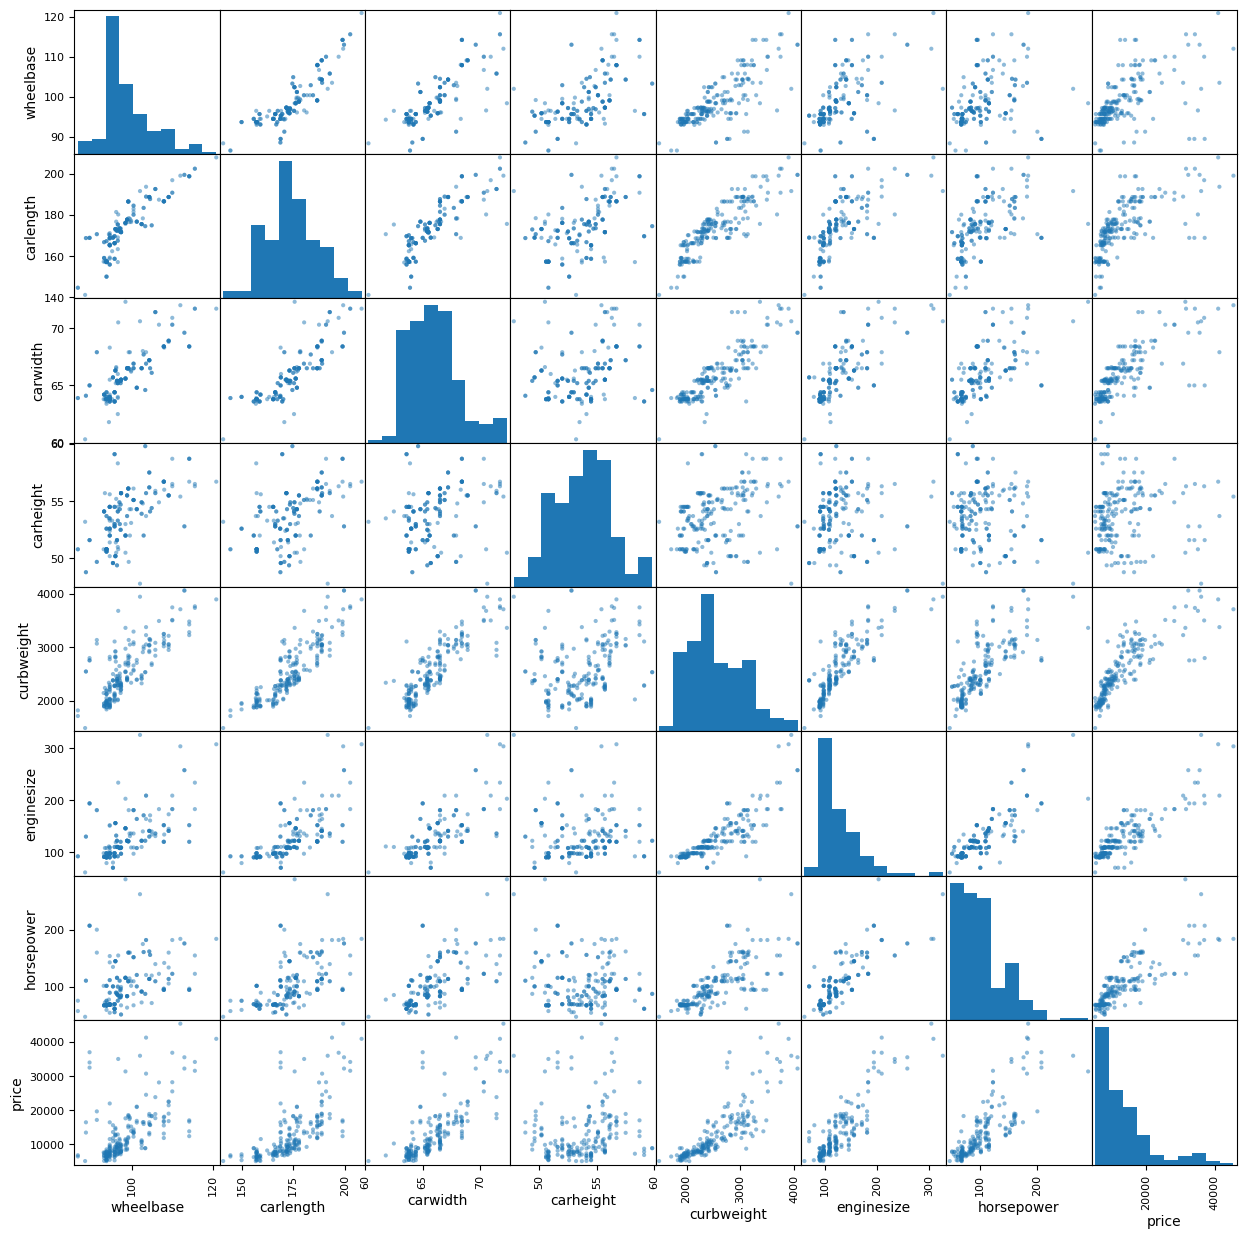

In [9]:
from pandas.plotting import scatter_matrix
import matplotlib.pyplot as plt

features = [
    'wheelbase',
    'carlength',
    'carwidth',
    'carheight',
    'curbweight',
    'enginesize',
    'horsepower',
    'price'
]

scatter_matrix(
    cp[features],
    figsize=(15, 15),
    diagonal='hist'
)

plt.show()

## Feature Enginnering

### Check categorical Columns

In [10]:
categorical_cols = cp.select_dtypes(include=['object']).columns

print(categorical_cols)

Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'carbody',
       'drivewheel', 'enginelocation', 'enginetype', 'cylindernumber',
       'fuelsystem'],
      dtype='object')


In [11]:
cp['CarName'].unique()

array(['alfa-romero giulia', 'alfa-romero stelvio',
       'alfa-romero Quadrifoglio', 'audi 100 ls', 'audi 100ls',
       'audi fox', 'audi 5000', 'audi 4000', 'audi 5000s (diesel)',
       'bmw 320i', 'bmw x1', 'bmw x3', 'bmw z4', 'bmw x4', 'bmw x5',
       'chevrolet impala', 'chevrolet monte carlo', 'chevrolet vega 2300',
       'dodge rampage', 'dodge challenger se', 'dodge d200',
       'dodge monaco (sw)', 'dodge colt hardtop', 'dodge colt (sw)',
       'dodge coronet custom', 'dodge dart custom',
       'dodge coronet custom (sw)', 'honda civic', 'honda civic cvcc',
       'honda accord cvcc', 'honda accord lx', 'honda civic 1500 gl',
       'honda accord', 'honda civic 1300', 'honda prelude',
       'honda civic (auto)', 'isuzu MU-X', 'isuzu D-Max ',
       'isuzu D-Max V-Cross', 'jaguar xj', 'jaguar xf', 'jaguar xk',
       'maxda rx3', 'maxda glc deluxe', 'mazda rx2 coupe', 'mazda rx-4',
       'mazda glc deluxe', 'mazda 626', 'mazda glc', 'mazda rx-7 gs',
       'mazda glc 

Step 1: Label Encode Binary Columns

In [12]:
cp['fueltype'] = cp['fueltype'].map({'gas': 0, 'diesel': 1})

cp['aspiration'] = cp['aspiration'].map({'std': 0, 'turbo': 1})

cp['doornumber'] = cp['doornumber'].map({'two': 0, 'four': 1})

cp['enginelocation'] = cp['enginelocation'].map({'front': 0, 'rear': 1})

Step 2: One-Hot Encode Multi-Class Columns




In [13]:
df = pd.get_dummies(
    cp,
    columns=[
        'carbody',
        'drivewheel',
        'enginetype',
        'cylindernumber',
        'fuelsystem'
    ],
    drop_first=True
)



Split and encode brand AND MODEL

In [14]:
df['Brand'] = df['CarName'].str.split().str[0]
df['Model'] = df['CarName'].str.split().str[1:].str.join(' ')

# One-hot encode Brand
df = pd.get_dummies(df, columns=['Brand'], drop_first=True)

In [15]:
print(cp.select_dtypes(include='object').columns)

Index(['CarName', 'carbody', 'drivewheel', 'enginetype', 'cylindernumber',
       'fuelsystem'],
      dtype='object')


In [16]:
cp = pd.get_dummies(
    cp,
    columns=[
        'carbody',
        'drivewheel',
        'enginetype',
        'cylindernumber',
        'fuelsystem'
    ],
    drop_first=True
)

Encoding into number




In [17]:
cp['Brand'] = cp['CarName'].str.lower().str.split().str[0]
print(cp[['CarName', 'Brand']].head())
print(cp.dtypes)

                    CarName        Brand
0        alfa-romero giulia  alfa-romero
1       alfa-romero stelvio  alfa-romero
2  alfa-romero Quadrifoglio  alfa-romero
3               audi 100 ls         audi
4                audi 100ls         audi
CarName                   object
fueltype                   int64
aspiration                 int64
doornumber                 int64
enginelocation             int64
wheelbase                float64
carlength                float64
carwidth                 float64
carheight                float64
curbweight                 int64
enginesize                 int64
boreratio                float64
stroke                   float64
compressionratio         float64
horsepower                 int64
price                    float64
carbody_hardtop             bool
carbody_hatchback           bool
carbody_sedan               bool
carbody_wagon               bool
drivewheel_fwd              bool
drivewheel_rwd              bool
enginetype_dohcv            

Label Encoder

In [19]:
from sklearn.preprocessing import LabelEncoder

car_encoder = LabelEncoder()
brand_encoder = LabelEncoder()

cp['CarName'] = car_encoder.fit_transform(cp['CarName'])
cp['Brand'] = brand_encoder.fit_transform(cp['Brand'])

In [20]:
print(cp[['CarName', 'Brand']].head())

   CarName  Brand
0        2      0
1        3      0
2        1      0
3        4      1
4        5      1


CO Relation after feature Engineering

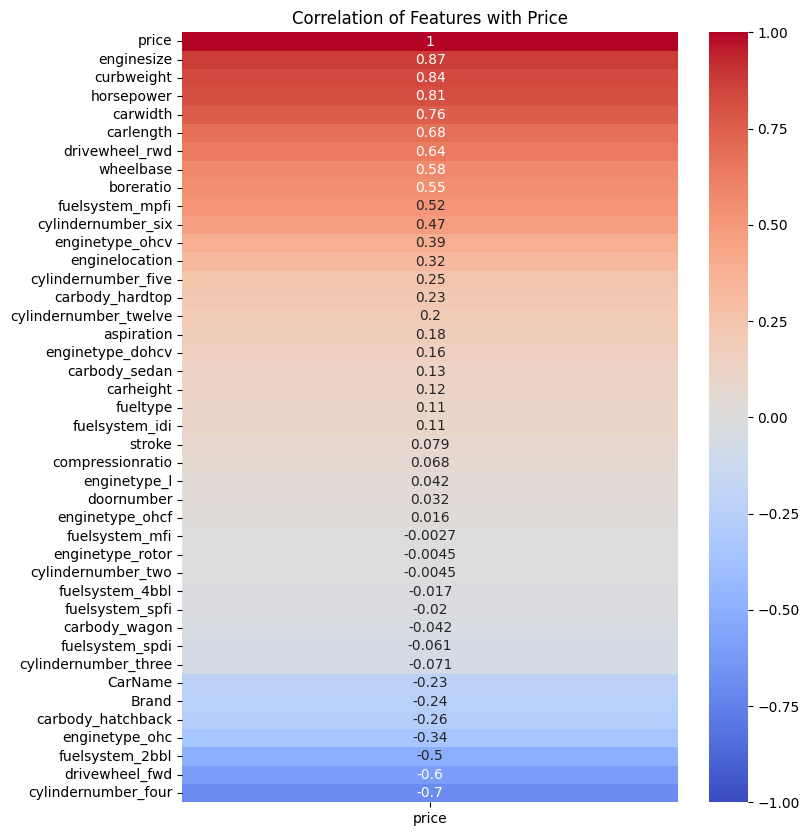

In [21]:
import seaborn as sns
import matplotlib.pyplot as plt

# Correlation matrix
corr_matrix = cp.corr(numeric_only=True)

# Correlation of all features with price
plt.figure(figsize=(8,10))
sns.heatmap(corr_matrix[['price']].sort_values(by='price', ascending=False),
            annot=True,
            cmap='coolwarm',
            vmin=-1,
            vmax=1)

plt.title("Correlation of Features with Price")
plt.show()

Some more dropping

In [23]:
# List of columns to drop
columns_to_drop = [
    'cylindernumber_three',
    'fuelsystem_spdi',
    'carbody_wagon',
    'fuelsystem_spfi',
    'fuelsystem_4bbl',
    'cylindernumber_two',
    'enginetype_rotor',
    'fuelsystem_mfi'
]

# Drop the columns
cp = cp.drop(columns=columns_to_drop)

# Check remaining columns
print(cp.columns)

Index(['CarName', 'fueltype', 'aspiration', 'doornumber', 'enginelocation',
       'wheelbase', 'carlength', 'carwidth', 'carheight', 'curbweight',
       'enginesize', 'boreratio', 'stroke', 'compressionratio', 'horsepower',
       'price', 'carbody_hardtop', 'carbody_hatchback', 'carbody_sedan',
       'drivewheel_fwd', 'drivewheel_rwd', 'enginetype_dohcv', 'enginetype_l',
       'enginetype_ohc', 'enginetype_ohcf', 'enginetype_ohcv',
       'cylindernumber_five', 'cylindernumber_four', 'cylindernumber_six',
       'cylindernumber_twelve', 'fuelsystem_2bbl', 'fuelsystem_idi',
       'fuelsystem_mpfi', 'Brand'],
      dtype='object')


## Split and Train

In [24]:
X = cp.drop('price', axis=1)
y = cp['price']

In [25]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [26]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

In [27]:
y_pred = model.predict(X_test)

In [28]:
from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)
import numpy as np

mae = mean_absolute_error(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
r2 = r2_score(y_test, y_pred)

print("MAE :", mae)
print("MSE :", mse)
print("RMSE:", rmse)
print("R² Score:", r2)

MAE : 1966.5614870104891
MSE : 8551159.675112417
RMSE: 2924.236596979187
R² Score: 0.8916807178070165


Feature Selection (Final Step)

Lastly, I experimented with dropping some features that had a weak negative correlation with the target variable. These features were expected to have minimal impact on the model's predictive performance.


# List of columns to drop
columns_to_drop = [
    'cylindernumber_three',
    'fuelsystem_spdi',
    'carbody_wagon',
    'fuelsystem_spfi',
    'fuelsystem_4bbl',
    'cylindernumber_two',
    'enginetype_rotor',
    'fuelsystem_mfi'
]

# Drop the columns
cp = cp.drop(columns=columns_to_drop)

Model Performance After Dropping the Features
MAE: 1966.56
MSE: 8,551,159.68
RMSE: 2924.24
R² Score: 0.8917
Model Performance Without Dropping the Features
MAE: 1989.78
MSE: 8,350,569.30
RMSE: 2889.74
R² Score: 0.8942

**Comparison and Conclusion**

The model performance changed only slightly after removing the selected features. Although the MAE improved slightly (1989.78 → 1966.56), the MSE and RMSE increased, and the R² score decreased slightly (0.8942 → 0.8917). This indicates that the removed features still contributed some useful information to the model. Therefore, keeping these features results in slightly better overall performance, even though their correlation with the target variable was relatively weak.

Final Conclusion: In this case, removing the weakly correlated features did not improve the model. Therefore, it is preferable to retain these features in the final model.